# Why does xarray need an *index*? (and when a **custom** one)

A coordinate is *just an array of labels*. So why doesn't xarray simply **scan that array** every time you call `.sel`? Why is there a whole separate `Index` object — and why would you ever write your *own*?

The one-line answer we build to: **an index lets xarray exploit the *structure* in your coordinates — order, a generating rule, even the topology of the space — to select from them ergonomically and efficiently.** The richer the structure you can name, the more a well-matched index exploits.

## Learning objectives

- See what a built-in `Index` buys you (ergonomics, alignment, fast lookups) and when it's automatic.
- Recognize when the *structure* of your coordinates outgrows the default index.
- Write your own index — both a full custom `Index` (periodicity) and a `CoordinateTransform` (a generating rule).

## The arc

**Built-in indexes** carry you a long way — a video's **time axis** (`PandasIndex`), a **too-big-to-store** regular axis (`RangeIndex`), and **slicing** across several dimensions at once.

**Write your own** when the structure is richer — a **metal ring** (heat on a periodic loop) needs a custom **`PeriodicIndex`**; coordinates from a **rule** need a **`CoordinateTransform`** (a ruler → an affine grid → a nonlinear warp). *These are the exercises.* 📝

**When there's no rule at all**, scattered points fall back to a KD‑tree (**`NDPointIndex`**).

*See also: the [Xarray Indexes Gallery](https://xarray-indexes.readthedocs.io/) · [how to create a custom index](https://docs.xarray.dev/en/stable/internals/how-to-create-custom-index.html) · [indexing user guide](https://docs.xarray.dev/en/stable/user-guide/indexing.html).*

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from xarray import Coordinates
from xarray.indexes import (
    CoordinateTransform,
    CoordinateTransformIndex,
    NDPointIndex,
    RangeIndex,
)


# helper reused later, when we get to the metal ring
def draw_circle(ax, r=1, lim=1.4):
    circ = plt.Circle((0, 0), r, fill=False, ls=":", color="0.7")
    ax.add_patch(circ)
    ax.set_aspect("equal")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


# a metal ring with 24 temperature sensors. A hot spot sits ON the seam (near 0°/360°)
# and cools slowly around the loop — like heat diffusing on a ring.
n = 24
angle = np.arange(0, 360, 360 // n)  # degrees: 0, 15, 30, ... 345  (monotonic!)
theta = np.deg2rad(angle)
x = np.cos(theta)
y = np.sin(theta)
d_seam = (angle - 0 + 180) % 360 - 180  # circular distance to the hot spot at 0°
temperature = 15 + 20 * np.exp(-(d_seam**2) / (2 * 45.0**2))  # broad, slowly-cooling peak
da = xr.DataArray(
    temperature,
    dims="angle",
    coords={"angle": angle, "x": ("angle", x), "y": ("angle", y)},
    name="temperature",
)

## 1.1 A coordinate is just an array of labels — a video's time axis

The most familiar index hides in plain sight. A video is just a **stack of frames**, and each frame happens at a **time**. That `time` axis is a coordinate — literally *an array of labels* — and it has exactly the structure the built-in [`PandasIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.PandasIndex.html) is built for: 1‑D and monotonic.

We'll open a short clip with a tiny xarray backend that reads image formats (`ocean.gif`), so the whole video arrives as an ordinary `Dataset` with dims `(time, height, width, color)`.

In [ ]:
# A little xarray backend (from the "Backends" tutorial) that reads image formats via imageio.
# It turns a gif/mp4 into a Dataset with dims (time, height, width, color).
import sys

sys.path.insert(0, "../../advanced/backends")
from imageio_ import ImageIOBackend

# .load() pulls the whole (small) clip into memory up front
ocean = xr.open_dataset("../../advanced/backends/ocean.gif", engine=ImageIOBackend).load()
ocean

Look at `time`: a `timedelta64` array running 0 → 1.7 s (18 frames at 100 ms each). It's nothing but a plain array of labels. So suppose you want *the frame nearest 0.8 s*.

### The naive way: scan the array yourself

You *could* do it by hand — measure the distance from every timestamp to 0.8 s and take the smallest:

In [ ]:
print("time is just an array of labels:", ocean.time.values[:4], "...")

target = np.timedelta64(800, "ms")
pos = np.abs(ocean.time.values - target).argmin()  # a full O(n) scan
print(f"nearest frame is index {pos}, at {ocean.time.values[pos] / np.timedelta64(1, 's'):g} s")

That works, but it's **manual plumbing** — you'd hand-write `nearest`, a time *range* needs more code, and combining two clips by timestamp (**alignment**) is a project of its own. None of it composes.

### Let the index do it

Because `time` is a **dimension coordinate**, xarray already built a `PandasIndex` for it — you never asked:

In [ ]:
ocean.xindexes  # time got a PandasIndex automatically (so did `color`, another dim coord)

In [ ]:
# select by timestamp (not by frame number!) — the index finds the nearest frame
frame = ocean.sel(time="0.8s", method="nearest")

# and a label RANGE, impossible to express as "scan for equality":
clip = ocean.sel(time=slice("0.5s", "1.2s"))
print("frames on the 0.5-1.2 s slice:", clip.sizes["time"])

seconds = frame.time.values / np.timedelta64(1, "s")
fig, ax = plt.subplots(figsize=(5, 3))
ax.imshow(frame["data"].values)
ax.set(title=f"sel(time='0.8s', nearest)  ->  t = {seconds:g} s", xticks=[], yticks=[])
plt.show()

In [ ]:
# 📝 Play with it: change these timestamps (in seconds) and re-run — .sel picks the nearest frame each time
times = ["0s", "0.4s", "0.8s", "1.2s", "1.6s"]

montage = ocean["data"].sel(time=times, method="nearest")
fig, axes = plt.subplots(1, len(times), figsize=(3 * len(times), 2))
for ax, t in zip(axes, montage.time.values):
    ax.imshow(montage.sel(time=t).values)
    ax.set(title=f"{t / np.timedelta64(1, 's'):g} s", xticks=[], yticks=[])
fig.suptitle("select frames by time — one .sel, no frame numbers", y=1.05)
plt.show()

### Recap: the 1‑D index

On a 1‑D, monotonic coordinate, the default [`PandasIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.PandasIndex.html) gives you, for free:

- **ergonomics** — `nearest`, `tolerance`, and label `slice` as one-liners
- **alignment** — automatic label joins in `+`, `concat`, `merge`
- **fast lookups** — a hash table for exact matches, binary search over the sorted labels for ranges and `nearest` (which is why those need a *monotonic* index)

You never asked for it — `time` being a dimension coordinate created the index automatically.

The idea to carry forward: **an index is a precomputed lookup structure, and the richer the structure in your coordinates, the more a well-matched index can exploit.** A plain sorted axis only has *order*. The rest of this notebook is about coordinates with *more* structure — too big to store, a periodic loop, a generating rule — and the indexes that exploit each.

## 1.2 Generated, not stored: `RangeIndex`

- A regular 1‑D axis can get *huge*: a 60 fps hour of video is ~216k frames; a microscopy stack, **billions** of planes.
- Materialized as `float64`, that's tens of GB for *one coordinate* — before touching a single voxel.
- But the labels are perfectly regular (`start + i·step`) — so **generate** them lazily instead of **storing** them.
- [`RangeIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.RangeIndex.html) keeps three numbers (`start`, `stop`, `step`). Still built-in, still 1‑D — just a smarter representation of the same coordinate.

<!-- TODO (prose): flesh out the motivation; the code below uses a 2-billion-plane EM stack. -->


In [ ]:
# a whole-brain EM stack: 2 billion z-planes at 4 nm spacing
n_z = 2_000_000_000
z = Coordinates.from_xindex(RangeIndex.arange(0.0, n_z * 4.0, 4.0, dim="z"))["z"]

print(
    f"{n_z:,} regularly-spaced labels — stored as 3 numbers, not "
    f"{n_z * 8 / 1e9:.0f} GB of array"
)
print("the coordinate is lazy:", type(z.variable._data).__name__)

# select by physical position (nm); only the requested points are ever computed
depth_nm = xr.DataArray([1e6, 5e6], dims="probe")  # 1 mm and 5 mm deep
print("nearest plane to each depth (nm):", z.sel(z=depth_nm, method="nearest").values)

- The labels never materialize — `z` is backed by a lazy `CoordinateTransformIndexingAdapter` (the *same* machinery we'll use to write our own index).
- `RangeIndex.sel` matches with `method="nearest"`: it's a continuous ruler, not a hash table.

<!-- TODO (prose): bridge into multi-dimensional slicing next. -->


## 1.3 Slicing in space *and* time

- One `.sel` selects across *several* dimensions at once — a time window **and** a spatial crop.
- Every dimension that has an index gets label-based slicing; here we give the pixel axes coordinates so space selects by label too.

<!-- TODO (prose): expand on multi-dim slicing / how the index does the work per axis. -->

In [ ]:
# give the pixel axes coordinates so BOTH space and time can be sliced by label
frames = ocean.assign_coords(
    height=("height", np.linspace(0, 1, ocean.sizes["height"])),
    width=("width", np.linspace(0, 1, ocean.sizes["width"])),
)

# one .sel across time AND space: a temporal window + a spatial box
clip = frames.sel(time=slice("0.2s", "0.7s"), height=slice(0.25, 0.75), width=slice(0.3, 0.7))
print("full:", dict(frames.sizes))
print("clip:", dict(clip.sizes))

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(frames["data"].isel(time=0).values)
axes[0].set(title="full frame", xticks=[], yticks=[])
axes[1].imshow(clip["data"].isel(time=0).values)
axes[1].set(title="sel(time, height, width)", xticks=[], yticks=[])
plt.show()

## 2. A metal ring: when the axis wraps around

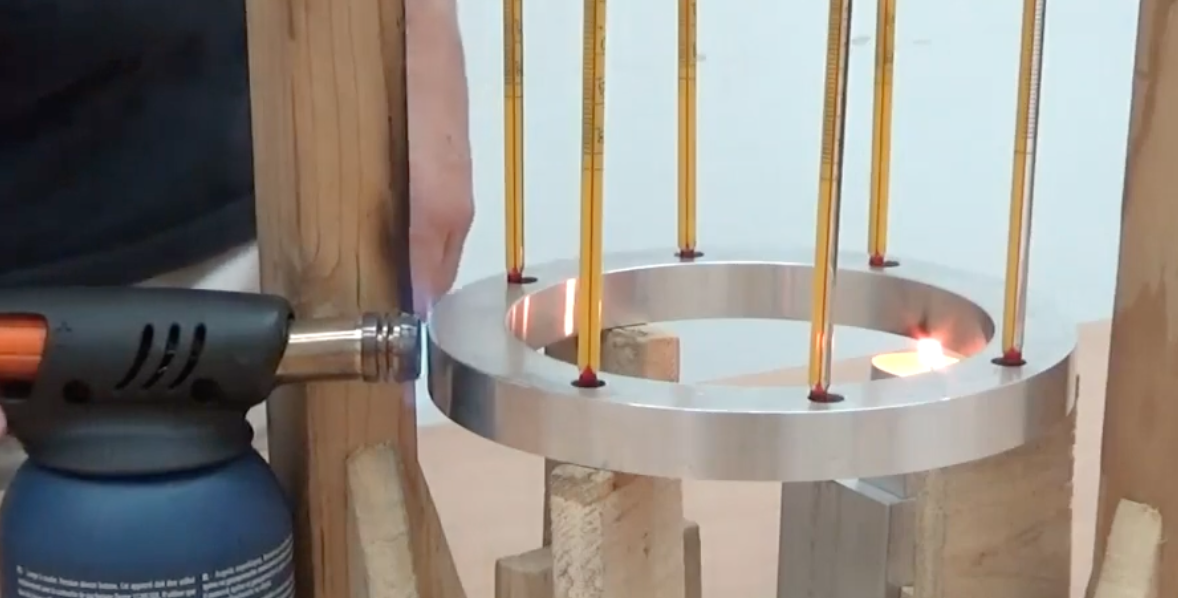

- Not every 1‑D coordinate lies on a straight line. A **metal ring** (heat diffusing around a loop) is a *periodic* coordinate: `345°` and `0°` are neighbors.
- Our hot spot sits **right on the seam** (near 0°/360°) — exactly where a linear index gets confused.
- The default `PandasIndex` treats `angle` as a **linear** axis `[0, 345]` — it has no idea the ends meet.

```{admonition} This is a real physical problem
:class: note
Heat flow around a ring is the classic *periodic boundary* problem — the one Fourier introduced Fourier series to solve. Temperature at `360°` **is** the temperature at `0°`, so the model has to know the axis wraps.

- 📺 [Fourier's experiments on the heating of a metal ring (video)](https://www.youtube.com/watch?v=O-zNVW7tFPQ&list=PLTGvK6jMx5QBhFJ27J4n7JGxHCnZ0USMf&index=6)
- 📄 [Reconstructing the early history of the theory of heat through Fourier's experiments (Eur. J. Phys.)](https://iopscience.iop.org/article/10.1088/1361-6404/acdf2e)
```

<!-- TODO (prose): consequences below — nearest, interp, and especially alignment all break across the seam. -->


In [ ]:
# a metal ring: 24 sensors, angle in [0, 360). The axis is PERIODIC (345° and 0° are neighbors).
metal_ring = da
print("angles:", metal_ring.angle.values)

fig, ax = plt.subplots(figsize=(5, 5))
draw_circle(ax)
sc = ax.scatter(metal_ring.x, metal_ring.y, c=metal_ring, cmap="coolwarm", s=140, zorder=3)
fig.colorbar(sc, ax=ax, label="temperature (°C)", shrink=0.8)
ax.set_title("A metal ring: a hot spot straddles the 360° → 0° seam")
plt.show()

In [ ]:
# the hot spot sits ON the seam (0°). The default index is LINEAR — it doesn't know 345° ≈ 0°.
# 'nearest to 358°' is really 0° (the ~35°C peak), but a linear index picks 345° and misses it:
got = metal_ring.sel(angle=358, method="nearest")
print(f"sel(358, nearest) -> angle {float(got.angle):g}°, {float(got):.1f}°C   (want 0°, the peak)")

# interpolating across the seam fails entirely: 352.5° is between 345° and 360°(=0°), off the linear end
print("interp(352.5)     ->", float(metal_ring.interp(angle=352.5).values), "°C   (NaN)")

In [ ]:
# a SECOND instrument samples the same ring but labels angles in [-180, 180)
alt_angle = np.arange(
    -180, 180, 30
)  # -180, -150, ..., 150  (same physical spots, different labels)
humidity = xr.DataArray(
    50 + 5 * np.sin(np.deg2rad(alt_angle)),
    dims="angle",
    coords={"angle": alt_angle},
    name="humidity",
)

# -30° (humidity) and 330° (metal_ring) are the SAME point — but the linear index can't see that
combined = metal_ring + humidity  # aligns by label; seam points silently dropped
print("labels kept after alignment:", combined.angle.values)
print("-> only the overlapping half survives; the seam mismatch loses the rest")

## 2.1 📝 Write your own: a `PeriodicIndex`

<!-- TODO (prose): we want an index that KNOWS the period, so selection respects the seam.
This is a full custom `Index` — and it can be tiny. -->

A full custom `Index` can be tiny — the only method that carries the idea is **`sel`**. We've filled in the boilerplate: `__init__` wraps a plain `PandasIndex` (which holds the labels) plus the `period`, and `from_variables` is how `set_xindex` builds it.

::::{admonition} Exercise — implement `sel`
:class: tip

Selection should **wrap around** the period. The trick is **circular distance**: fold the gap between a query and each label into `[-period/2, +period/2)`, then take the nearest.

```python
def sel(self, labels, method=None, tolerance=None):
    (name, label), = labels.items()
    base = self._index.index.to_numpy()   # the stored labels (one period)
    q = np.asarray(label, dtype=float)
    ...  # circular distance -> nearest position
    return IndexSelResult({self._index.dim: indexer})
```

:::{admonition} Solution
:class: dropdown
```python
def sel(self, labels, method=None, tolerance=None):
    (name, label), = labels.items()
    base = self._index.index.to_numpy()
    q = np.asarray(label, dtype=float)
    d = np.abs((q[..., None] - base + self.period / 2) % self.period - self.period / 2)
    pos = d.argmin(axis=-1)
    if q.ndim == 0:
        indexer = int(pos)                       # scalar query
    elif hasattr(label, "dims"):
        indexer = xr.Variable(label.dims, pos)   # vectorized query
    else:
        indexer = pos                            # 1-D array query
    return IndexSelResult({self._index.dim: indexer})
```
:::
::::

> **Only what you need.** A *production* index might add two more methods, but selecting on one array needs neither: `create_variables` (only if the index **generates** its coordinate — that's what a `CoordinateTransform` does, next) and `equals` (only to align two *different* periodic datasets).

In [ ]:
from xarray import Index
from xarray.core.indexing import IndexSelResult
from xarray.indexes import PandasIndex


class PeriodicIndex(Index):
    """A 1-D index whose axis wraps every ``period`` (e.g. angle, period=360)."""

    def __init__(self, pandas_index, period):
        self._index = pandas_index  # a plain PandasIndex holding the labels
        self.period = period

    @classmethod
    def from_variables(cls, variables, *, options):
        # boilerplate: how set_xindex builds us from the coordinate
        return cls(PandasIndex.from_variables(variables, options={}), options["period"])

    def sel(self, labels, method=None, tolerance=None):
        ((name, label),) = labels.items()
        base = self._index.index.to_numpy()
        q = np.asarray(label, dtype=float)
        # circular distance from each query to every label; nearest wins
        d = np.abs((q[..., None] - base + self.period / 2) % self.period - self.period / 2)
        pos = d.argmin(axis=-1)
        if q.ndim == 0:
            indexer = int(pos)
        elif hasattr(label, "dims"):
            indexer = xr.Variable(label.dims, pos)
        else:
            indexer = pos
        return IndexSelResult({self._index.dim: indexer})

In [ ]:
# attach OUR index (period = 360) to the metal ring
periodic = metal_ring.drop_indexes("angle").set_xindex("angle", PeriodicIndex, period=360.0)

# selection now respects the ring's topology — no seam, no wrap-around bookkeeping
got = periodic.sel(angle=358)
print(
    f"sel(358) -> angle {float(got.angle):g}°, {float(got):.1f}°C   (0°, the hot peak — correct!)"
)
print("sel([350, 5, 370]) ->", periodic.sel(angle=np.array([350, 5, 370])).angle.values)

In [ ]:
# the payoff: read the [-180, 180) instrument at every ring angle — the seam is handled for us
hum_p = humidity.drop_indexes("angle").set_xindex("angle", PeriodicIndex, period=360.0)
h_here = hum_p.sel(angle=metal_ring.angle.values).values  # folds 330° <-> -30°, etc.
paired = metal_ring.assign_coords(humidity=("angle", h_here))

print(
    "humidity paired at 330° ->",
    float(paired.humidity.sel(angle=330)),
    " == humidity(-30°):",
    float(humidity.sel(angle=-30)),
)
print("all", paired.sizes["angle"], "ring angles paired — nothing dropped across the seam")

## 3. Build your own index — the simplest rule (1-D)

<!-- TODO (prose): RangeIndex was the built-in solution for a regular 1-D axis. Now we build our OWN
indexes with CoordinateTransform, in three steps of increasing power: a 1-D ruler (here), a 2-D
affine grid (§4), and a nonlinear warp (§5). -->

Continuing the theme of scale: real imaging volumes are enormous — a mouse brain at EM resolution is on the order of an **exabyte**, and even a fly brain is a large stack of slices. You can't store a coordinate label per slice. But slice *k* sits at a known physical **depth** — `depth = k · thickness` — so store the *rule*, not a depth array.

<!-- IMAGE: fly-brain slice stack — user to provide -->

A `CoordinateTransform` needs just two methods (we fill in the `__init__` boilerplate):

- `forward` — slice index → depth
- `reverse` — depth → slice index

::::{admonition} Exercise — implement the ruler
:class: tip

Fill in `forward` and `reverse` so the transform maps slice index ↔ depth (`depth = index · thickness`).

```python
class SliceRuler(CoordinateTransform):
    def __init__(self, n, thickness):
        super().__init__(("depth",), {"slice": n})
        self.n, self.thickness = n, thickness

    def forward(self, dim_positions):     # slice index -> depth
        ...

    def reverse(self, coord_labels):      # depth -> slice index
        ...
```

:::{admonition} Solution
:class: dropdown
```python
    def forward(self, dim_positions):     # slice index -> depth
        return {"depth": dim_positions["slice"] * self.thickness}

    def reverse(self, coord_labels):      # depth -> slice index
        return {"slice": coord_labels["depth"] / self.thickness}
```
:::
::::

In [ ]:
class SliceRuler(CoordinateTransform):
    """1-D: slice index  <->  physical depth (µm).   depth = index * thickness"""

    def __init__(self, n, thickness):
        super().__init__(("depth",), {"slice": n})
        self.n, self.thickness = n, thickness

    def forward(self, dim_positions):  # slice index -> depth
        return {"depth": dim_positions["slice"] * self.thickness}

    def reverse(self, coord_labels):  # depth -> slice index
        return {"slice": coord_labels["depth"] / self.thickness}

In [ ]:
# an imaging stack: 200 slices, 0.5 µm apart. We store the RULE, not a depth-per-slice array
# (a real volume has millions of slices — you couldn't store the labels).
n_slices, thickness = 200, 0.5  # µm
depth_true = np.arange(n_slices) * thickness
structure = np.exp(-((depth_true - 50.0) ** 2) / (2 * 8.0**2))  # a bright band ~50 µm deep
rng = np.random.default_rng(0)
volume = xr.DataArray(
    structure[:, None, None] * rng.random((n_slices, 32, 32)),  # stand-in for the image data
    dims=("slice", "y", "x"),
    coords=Coordinates.from_xindex(CoordinateTransformIndex(SliceRuler(n_slices, thickness))),
    name="intensity",
)
volume  # 'depth' is a lazy coordinate, generated by the rule

In [ ]:
# grab the slice nearest a physical depth (µm) in one call — only the rule (n, thickness) is stored
volume.sel(depth=xr.DataArray([10.0, 50.0, 73.3], dims="d"), method="nearest")

In [ ]:
# mean intensity vs depth — the x-axis is the 'depth' coordinate, generated on demand by the rule
volume.mean(["y", "x"]).plot(x="depth")
plt.gca().set(xlabel="depth (µm)", title="brightness vs depth (structure ~50 µm deep)")
plt.show()

### You just built a DIY `RangeIndex`

A 1‑D coordinate generated from a rule (`start + i·step`), never stored — that's *exactly* what the built‑in [`RangeIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.RangeIndex.html) did for the brain stack earlier. Same machinery (`CoordinateTransformIndex` + a lazy adapter), just packaged. **So for a plain regular axis, reach for `RangeIndex`** — you now know what's inside it. Writing your own `CoordinateTransform` earns its keep when the rule is something xarray *doesn't* ship — starting with a 2‑D grid next.

## 4. Step up to 2-D: a regular grid

The ruler was 1-D. Real spatial data is 2-D — and `NDPointIndex` would treat it as an unstructured cloud and build a tree. But a **regular grid** has structure a tree throws away: every cell's world position comes from an affine rule

$$x = x_0 + i\,\Delta x, \qquad y = y_0 + j\,\Delta y$$

so you needn't *store* `x` / `y`, and you needn't build a tree — selection just **inverts the arithmetic**. Same two methods as the ruler, now with two dimensions:

- `forward` — grid indices `(i, j)` → world `(x, y)`
- `reverse` — world `(x, y)` → grid indices

::::{admonition} Exercise — build the 2-D affine grid
:class: tip

Now the real thing. Implement `forward` and `reverse` for the affine rule above: integer grid indices (`"xi"` = i, `"yj"` = j) ↔ world `(x, y)`. `reverse` is just the inverse arithmetic — fractional indices are fine, xarray rounds for `nearest`.

```python
class AffineGridTransform(CoordinateTransform):
    def __init__(self, x0, y0, dx, dy, nx, ny):
        super().__init__(("x", "y"), {"yj": ny, "xi": nx})
        self.x0, self.y0, self.dx, self.dy = x0, y0, dx, dy

    def forward(self, dim_positions):     # (i, j) -> (x, y)
        ...

    def reverse(self, coord_labels):      # (x, y) -> (i, j)
        ...
```

:::{admonition} Solution
:class: dropdown
```python
    def forward(self, dim_positions):     # (i, j) -> (x, y)
        return {"x": self.x0 + dim_positions["xi"] * self.dx,
                "y": self.y0 + dim_positions["yj"] * self.dy}

    def reverse(self, coord_labels):      # (x, y) -> (i, j)
        return {"xi": (coord_labels["x"] - self.x0) / self.dx,
                "yj": (coord_labels["y"] - self.y0) / self.dy}
```
:::
::::

In [ ]:
class AffineGridTransform(CoordinateTransform):
    """Regular grid: indices (i along 'xi', j along 'yj')  <->  world (x, y)."""

    def __init__(self, x0, y0, dx, dy, nx, ny):
        super().__init__(("x", "y"), {"yj": ny, "xi": nx})
        self.x0, self.y0, self.dx, self.dy = x0, y0, dx, dy

    def forward(self, dim_positions):  # grid -> world:  x = x0 + i*dx,  y = y0 + j*dy
        return {
            "x": self.x0 + dim_positions["xi"] * self.dx,
            "y": self.y0 + dim_positions["yj"] * self.dy,
        }

    def reverse(self, coord_labels):  # world -> grid:  the inverse
        return {
            "xi": (coord_labels["x"] - self.x0) / self.dx,
            "yj": (coord_labels["y"] - self.y0) / self.dy,
        }

In [ ]:
# a 12x9 world grid — 6 numbers (x0, y0, dx, dy + shape) place every cell; x/y aren't stored
tr = AffineGridTransform(x0=-3.0, y0=2.0, dx=0.5, dy=-0.5, nx=12, ny=9)
grid = xr.DataArray(
    np.arange(9 * 12).reshape(9, 12).astype(float),
    dims=("yj", "xi"),
    coords=Coordinates.from_xindex(CoordinateTransformIndex(tr)),
    name="field",
)

# THE POINT: select by world (x, y); the index inverts the affine rule to find the cell
cell = grid.sel(
    x=xr.DataArray([-1.1], dims="q"), y=xr.DataArray([0.9], dims="q"), method="nearest"
).isel(q=0)

assert grid.x.dims == ("yj", "xi")  # coords span both grid dims
assert (float(cell.x), float(cell.y)) == (-1.0, 1.0)  # inverse affine landed in the right cell
print("x / y generated by the rule, nothing stored:", type(grid.x.variable._data).__name__)

fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(grid.x.values, grid.y.values, c=grid.values, cmap="viridis", s=90, marker="s")
fig.colorbar(sc, ax=ax, label="field", shrink=0.85)
ax.scatter([-1.1], [0.9], marker="*", s=340, c="crimson", zorder=5, label="query (x, y)")
ax.scatter(
    [float(cell.x)],
    [float(cell.y)],
    edgecolor="k",
    facecolor="none",
    s=280,
    lw=2,
    zorder=6,
    label="nearest cell (inverse affine)",
)
ax.set_aspect("equal")
ax.set_xlabel("world x")
ax.set_ylabel("world y")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.32))
ax.set_title("Regular grid: sel(x, y) inverts the affine rule")
plt.show()

### The built-in twin: affine rasters in the gallery

That's a working custom index in a handful of lines. On a regular grid it beats `NDPointIndex` cleanly: **no coordinate arrays are stored** (they come from 6 numbers) and **there's no tree to build or search** — selection is one subtract‑and‑divide per axis. That's the "exploit the structure" payoff: when you *know* the rule, the index barely has to work.

And — just as the ruler was a DIY `RangeIndex` — you rarely need to write this one yourself either. The *same* `CoordinateTransform` pattern powers production indexes for **affine rasters, rotated‑pole grids, and map projections**: see [`rasterix`](https://github.com/dcherian/rasterix)'s `RasterIndex` (a GDAL‑style affine geotransform) and more in the [Xarray Indexes Gallery](https://xarray-indexes.readthedocs.io/). You write your own only when the rule is one nobody's packaged yet — like the fisheye lens next.

## 5. 🔍 Level 2 — a fisheye lens: a *nonlinear* rule

Our scenario: a fisheye camera photographs a flat checkerboard. The **image is distorted**, the **world is flat**, and we want to ask questions in *world* coordinates.

**The distortion model, up front.** We keep ordinary **Cartesian** world coordinates `(x, y)` — a lens doesn't change that. What it changes is *radial*: a point's **direction** from the image centre is preserved, only its **distance** is stretched, by a factor that depends on the radius `r = √(x² + y²)`. Our model (the "division" model):

$$(x_\text{world},\, y_\text{world}) = (x,\, y)\;\cdot\;\frac{1}{1 - k\,r^2}, \qquad r = \sqrt{x^2 + y^2}$$

Straight lines bow outward — **barrel** distortion. Because the factor depends on `r`, each world coordinate depends on **both** pixel axes; that "radial" coupling is exactly why two independent 1-D coordinates can't describe it, and we need a 2-D transform.

Let's start with the data:

In [ ]:
SQUARES = (
    1.5  # checkerboard squares per world unit (shared by the checker + the world-grid overlay)
)


def checker(x, y, squares=SQUARES):
    return ((np.floor(x * squares) + np.floor(y * squares)) % 2).astype(float)


nx = ny = 1024
k = 0.35  # lens distortion strength

# each sensor pixel looks out at a world point through the lens (radial model)
y_pixel, x_pixel = np.meshgrid(np.arange(ny), np.arange(nx), indexing="ij")
x_norm = (x_pixel - (nx - 1) / 2) / ((nx - 1) / 2)  # centered, normalized pixel coords
y_norm = (y_pixel - (ny - 1) / 2) / ((ny - 1) / 2)
factor = 1 / (1 - k * np.hypot(x_norm, y_norm) ** 2)  # fisheye: the periphery expands (barrel)
x_world, y_world = x_norm * factor, y_norm * factor  # the world position each pixel sees

photo = checker(x_world, y_world)  # a flat checkerboard, seen through the lens
photo_da = xr.DataArray(
    photo,
    dims=("y_pixel", "x_pixel"),
    coords={"x_pixel": np.arange(nx), "y_pixel": np.arange(ny)},
    name="brightness",
)
photo_da  # our data: a plain, pixel-indexed image

In [ ]:
photo_da.plot()

In [ ]:
# the flat world (the scene) vs the distorted photo (our data)
world_grid = np.linspace(-1.6, 1.6, 400)
flat = checker(*np.meshgrid(world_grid, world_grid))

fig, (ax_world, ax_photo) = plt.subplots(1, 2, figsize=(10.5, 5.2))
ax_world.imshow(flat, cmap="gray", origin="lower", extent=[-1.6, 1.6, -1.6, 1.6])
ax_world.set_title("REAL WORLD — flat checkerboard")
ax_world.set_xlabel("x_world")
ax_world.set_ylabel("y_world")
ax_photo.imshow(photo, cmap="gray", origin="lower")
ax_photo.set_title("STORED fisheye photo — DISTORTED (our data)")
ax_photo.set_xlabel("x_pixel")
ax_photo.set_ylabel("y_pixel")
plt.show()

### Attempt 1 (the intuitive thing): store the undistorted coordinates

The obvious move: attach `x_world` and `y_world` as **coordinate variables** and select on them. Let's try it:

In [ ]:
# Attempt 1: store the world coords as 2-D coordinate variables (on the pixel dims)
distorted = xr.DataArray(
    photo,
    dims=("y_pixel", "x_pixel"),
    coords={
        "x_world": (("y_pixel", "x_pixel"), x_world),
        "y_world": (("y_pixel", "x_pixel"), y_world),
    },
    name="brightness",
)
distorted

In [ ]:
# select by world position -- the natural thing to try
try:
    distorted.sel(x_world=0.3, y_world=0.15, method="nearest")
except Exception as e:
    print("💥", type(e).__name__, ":", str(e))

**It breaks.** A coordinate *variable* is just labels — to `.sel` on it you need an **index**, and xarray can't auto-build the default `PandasIndex` here because these coordinates are **2‑D** (`PandasIndex` is 1‑D only). Storing the array bought us nothing for selection.

### Attempt 2: put an `NDPointIndex` on the stored coordinates

We *can* index 2‑D coordinates — give them a KD‑tree:

In [ ]:
point_indexed = distorted.set_xindex(["x_world", "y_world"], NDPointIndex)
point_indexed.sel(
    x_world=xr.DataArray([0.3, -0.5], dims="q"),
    y_world=xr.DataArray([0.15, 0.4], dims="q"),
    method="nearest",
)

### The better fix: the coordinates follow a *rule*

Those `x_world`/`y_world` arrays didn't fall from the sky — we *computed* them from the lens rule stated at the top. So encode the **rule**, not its samples. That radial rule has a closed-form inverse:

$$\text{world } r = \frac{\text{pixel } r}{1 - k\,(\text{pixel } r)^2} \qquad\Longleftrightarrow\qquad \text{pixel } r = \frac{-1 + \sqrt{1 + 4k\,(\text{world } r)^2}}{2k\,(\text{world } r)}$$

so `forward` applies the lens (pixel → world) and `reverse` undoes it (world → pixel):

In [ ]:
class FisheyeTransform(CoordinateTransform):
    """Radial fisheye lens: pixel (x_pixel, y_pixel) <-> world (x_world, y_world).
    world_r = pixel_r / (1 - k * pixel_r**2)  — barrel, with a closed-form inverse."""

    def __init__(self, nx, ny, k):
        super().__init__(("x_world", "y_world"), {"y_pixel": ny, "x_pixel": nx})
        self.nx, self.ny, self.k = nx, ny, k

    def _normalize(self, x_pixel, y_pixel):  # pixel indices -> centered, normalized
        return (
            (np.asarray(x_pixel) - (self.nx - 1) / 2) / ((self.nx - 1) / 2),
            (np.asarray(y_pixel) - (self.ny - 1) / 2) / ((self.ny - 1) / 2),
        )

    def forward(self, dim_positions):  # pixel -> world (undistort)
        x_norm, y_norm = self._normalize(dim_positions["x_pixel"], dim_positions["y_pixel"])
        factor = 1 / (1 - self.k * np.hypot(x_norm, y_norm) ** 2)
        return {"x_world": x_norm * factor, "y_world": y_norm * factor}

    def reverse(self, coord_labels):  # world -> pixel (distort, closed form)
        x_world = np.asarray(coord_labels["x_world"])
        y_world = np.asarray(coord_labels["y_world"])
        world_r = np.hypot(x_world, y_world)
        with np.errstate(divide="ignore", invalid="ignore"):
            pixel_r = (-1 + np.sqrt(1 + 4 * self.k * world_r**2)) / (2 * self.k * world_r)
            scale = np.where(world_r > 0, pixel_r / world_r, 1.0)
        return {
            "x_pixel": (x_world * scale) * ((self.nx - 1) / 2) + (self.nx - 1) / 2,
            "y_pixel": (y_world * scale) * ((self.ny - 1) / 2) + (self.ny - 1) / 2,
        }

    def equals(self, other, exclude=None):
        return isinstance(other, FisheyeTransform) and (self.nx, self.ny, self.k) == (
            other.nx,
            other.ny,
            other.k,
        )


# one lens instance drives both the index AND the manual reverse() calls in later cells
lens = FisheyeTransform(nx, ny, k)

# the world coords are GENERATED from the rule — note they are lazy in the repr below
fish = xr.DataArray(
    photo,
    dims=("y_pixel", "x_pixel"),
    coords=Coordinates.from_xindex(CoordinateTransformIndex(lens)),
    name="brightness",
)
fish

In [ ]:
# what the lens does, as a grid: a regular WORLD grid drawn on the photo bends into curves
t = np.linspace(-1.4, 1.4, 200)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.imshow(photo, cmap="gray", origin="lower")
for c in np.arange(-1.5, 1.6, 0.5):
    v = lens.reverse({"x_world": np.full_like(t, c), "y_world": t})
    h = lens.reverse({"x_world": t, "y_world": np.full_like(t, c)})
    ax.plot(v["x_pixel"], v["y_pixel"], c="tab:red", lw=1)
    ax.plot(h["x_pixel"], h["y_pixel"], c="tab:red", lw=1)
ax.set_xlim(0, nx - 1)
ax.set_ylim(0, ny - 1)
ax.set_xlabel("x_pixel")
ax.set_ylabel("y_pixel")
ax.set_title("a regular WORLD grid, drawn on the photo — the lens curves it")
plt.show()

In [ ]:
# a regular WORLD grid (straight lines) with the captured data on top:
# the "star" is just the patch of the flat world the fisheye actually saw
fig, ax = plt.subplots(figsize=(6, 6))
for c in np.arange(-4, 4.01, 1 / SQUARES):  # spacing = one checkerboard square in world
    ax.axhline(c, color="tab:red", lw=0.6, alpha=0.7)
    ax.axvline(c, color="tab:red", lw=0.6, alpha=0.7)
fish.plot(x="x_world", y="y_world", ax=ax, cmap="gray", add_colorbar=False)
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_aspect("equal")
ax.set_title("the fisheye captures a star-shaped patch of the regular world grid")
plt.show()

### The payoff: selecting in *world* coordinates

Now that `fish` is indexed by **world** `(x_world, y_world)`, questions about the *scene* are one-liners — even though the data is a distorted photo. On the raw pixels you'd invert the lens by hand for every query, and a straight world line is a **curved path** across the sensor.

- **A point** — is world `(0.3, 0.2)` black or white? (`0` = black, `1` = white)
- **A line** — read the brightness along a straight world line: `.sel` gives the true, regular square wave, while a naive pixel row (`.isel`) gives a *warped* one.

In [ ]:
# is the world point (0.3, 0.2) black or white?  — the result carries the world coords it resolved to
fish.sel(x_world=xr.DataArray(0.3), y_world=xr.DataArray(0.2), method="nearest")

In [ ]:
# THE POINT: a straight line in the WORLD (y_world = 0.2), sampled in one .sel call
line_x = np.linspace(-1.0, 1.0, 200)
line = fish.sel(
    x_world=xr.DataArray(line_x, dims="s"),
    y_world=xr.DataArray(np.full_like(line_x, 0.2), dims="s"),
    method="nearest",
)
print("sampled", line.sizes["s"], "points along the world line in a single call")

# --- plotting: that same straight world line traces a CURVE across the pixels ---
# (by hand, via the lens' reverse() — exactly the work .sel just did for us)
path = lens.reverse({"x_world": line_x, "y_world": np.full_like(line_x, 0.2)})
point = lens.reverse({"x_world": np.array([0.3]), "y_world": np.array([0.2])})
flat = checker(*np.meshgrid(np.linspace(-1.6, 1.6, 400), np.linspace(-1.6, 1.6, 400)))

fig, (ax_world, ax_photo) = plt.subplots(1, 2, figsize=(11, 5.2))
ax_world.imshow(flat, cmap="gray", origin="lower", extent=[-1.6, 1.6, -1.6, 1.6])
ax_world.plot(line_x, np.full_like(line_x, 0.2), c="tab:red", lw=2.5)
ax_world.scatter([0.3], [0.2], c="tab:orange", s=160, marker="*", zorder=5)
ax_world.set_title("WORLD — straight line:  sel(x_world=.., y_world=0.2)")
ax_photo.imshow(photo, cmap="gray", origin="lower")
ax_photo.plot(path["x_pixel"], path["y_pixel"], c="tab:red", lw=2.5)
ax_photo.scatter(point["x_pixel"], point["y_pixel"], c="tab:orange", s=160, marker="*", zorder=5)
ax_photo.set_title("PHOTO — the same selection is a curved path")
plt.show()

In [ ]:
# read the brightness ALONG the line: world selection is a clean square wave; a raw pixel row is warped
world_line = fish.sel(
    x_world=xr.DataArray(np.linspace(-1.4, 1.4, 400), dims="s"),
    y_world=xr.DataArray(np.zeros(400), dims="s"),
    method="nearest",
)
pixel_row = fish.isel(y_pixel=ny // 2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4.2), sharex=True)
ax1.step(np.linspace(0, 1, world_line.sizes["s"]), world_line.values, where="mid", c="tab:red")
ax1.set_title("along the WORLD line  (.sel by x_world) — even bands")
ax2.step(np.linspace(0, 1, pixel_row.sizes["x_pixel"]), pixel_row.values, where="mid", c="tab:blue")
ax2.set_title("along a raw PIXEL row  (.isel) — bands warp with the lens")
for ax in (ax1, ax2):
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["black", "white"])
ax2.set_xlabel("fraction along the line")
fig.tight_layout()
plt.show()

### Three ways, one lesson

| Approach | `.sel` by world coords? | Cost |
|---|---|---|
| store `(x_world, y_world)` as coord vars, *no index* | ❌ **breaks** (2‑D coord → no `PandasIndex`) | — |
| stored coords **+ `NDPointIndex`** | ✅ works (nearest *sampled* pixel) | stores both arrays (~256 MB for 4000²) + builds a tree |
| **`FisheyeTransform`** (the rule) | ✅ works (exact analytic inverse) | ~3 numbers, coords lazy, no tree |

So *"why not just add a second coordinate variable?"* — because a coordinate variable alone can't be selected on (you need an index), and a 2‑D one can't take the default index at all. Once you're attaching a custom index either way, encoding the **rule** beats storing its samples: it's **exact** (not nearest-over-samples), **lazy** (nothing stored), resolution-independent, and aligns by comparing a few parameters.

**The honest boundary:** if the mapping is *only* known as sampled arrays — a measured calibration map, or a model's curvilinear grid with no formula — then storing the coordinates **+ `NDPointIndex` is exactly right** (that's the curvilinear-grid case). The transform wins when you have an analytic **rule**, and a lens is the poster child.

> 📝 **Stretch exercise:** swap the division model for [Brown–Conrady](https://en.wikipedia.org/wiki/Distortion_(optics)) radial distortion $r_d = r_u(1 + k_1 r_u^2 + k_2 r_u^4)$. `forward` is easy; `reverse` has no closed form — solve it with a few Newton iterations inside `reverse`.

### Does the index even need coordinate *variables* — and are they materialized?

Look back at `fish`: `x_world` and `y_world` appear as coordinates, but they're **lazy** — a `CoordinateTransformIndexingAdapter`, conjured from the rule on demand and never stored. So *"do we absolutely need the `x_world`/`y_world` arrays?"* → **no.** We need the *rule*; the coordinates are generated from it.

**Crucially, `Coordinates.from_xindex(index)` does not instantiate anything.** It asks the index for its coordinate variables via `create_variables()`, and a `CoordinateTransform` hands them back wrapped in a lazy `CoordinateTransformIndexingAdapter` — no arrays allocated. The transform's `forward` runs only when you actually *touch* values (`.values`, plotting, arithmetic), and only for the slice you index. A 4000² fisheye coordinate therefore costs ~nothing until used, and selecting a handful of points computes only those points.

But the index does need to **expose** those coordinates *by name*: `.sel(x_world=…)` finds the index registered for the coordinate `x_world` and calls its `sel`. You can't select by a label that isn't a coordinate — so the coordinate must **exist**, it just needn't be **materialized**. (Plotting is the same: `fish.plot(x="x_world", y="y_world")` reads those values, realizing them through `forward` — the index's coordinate *generation*, not its `sel`.)

This is exactly how the built-in [`RangeIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.RangeIndex.html) works: a 1‑D coordinate generated lazily (the *same* adapter) from `start`/`stop`/`step`, with no backing array. Our fisheye is the 2‑D, nonlinear cousin: **the data is indexed by pixels, but selectable in world space**, the world coordinates existing only as a lazy view.

## 6. Coda — when there's no rule: `NDPointIndex`

Everything so far exploited *known* structure — order, a generating rule, a period. When coordinates are genuinely **scattered** with no formula to exploit, you fall back to a spatial tree.

<!-- TODO (prose): frame the coda. Below: a clean circle's (x, y) query still collapses to 1-D (angle), but a NOISY ring is truly 2-D, so we reach for a KD-tree via NDPointIndex. -->

### Selecting by *position* (x, y)

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
draw_circle(ax)
ax.scatter(da.x, da.y, c="0.85", s=90, zorder=2)
ax.axvline(0.5, color="tab:purple", ls="--", label="x = 0.5")
hits = da.where(np.abs(da.x - 0.5) < 0.02, drop=True)
ax.scatter(hits.x, hits.y, c="tab:purple", s=180, zorder=3)
for a in hits["angle"].values:
    p = da.sel(angle=a)
    ax.annotate(
        f"{a}°",
        (float(p.x), float(p.y)),
        textcoords="offset points",
        xytext=(10, 0),
        fontweight="bold",
    )
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2))
ax.set_title("x = 0.5 is ambiguous: two sensors match")
plt.show()

### ...but on the circle, a full `(x, y)` query is *still* 1‑D

Giving *both* `x` and `y` removes the ambiguity. But here's the twist that decides whether we even need a 2‑D index: **the nearest sensor to *any* point in the plane is simply the one in its direction from the centre.** Writing $P$ for the query, the distance to a sensor at angle $\theta$ is

$$d^2 = |P|^2 + R^2 - 2R\,|P|\cos(\varphi - \theta), \qquad \varphi = \operatorname{atan2}(y, x)$$

and only the $\cos(\varphi - \theta)$ term chooses the winner — minimised by the sensor whose **angle** is closest to $\varphi$, *no matter how far $P$ is from the circle*. So `(x, y)` selection collapses straight back to a 1‑D angle lookup:

In [ ]:
rng = np.random.default_rng(0)
Q = rng.uniform(-1.6, 1.6, (3000, 2))  # query points scattered all over the plane
cx, cy = da.x.values, da.y.values

# true nearest by full 2-D distance ...
by_2d = ((Q[:, 0, None] - cx) ** 2 + (Q[:, 1, None] - cy) ** 2).argmin(1)
# ... vs nearest by ANGLE alone (a 1-D lookup)
phi = np.arctan2(Q[:, 1], Q[:, 0]) % (2 * np.pi)
by_angle = np.rint(phi / (2 * np.pi) * n).astype(int) % n

print(f"1-D angle == full 2-D nearest for {(by_2d == by_angle).mean() * 100:.0f}% of queries")
print("=> on a clean circle, even (x, y) selection needs no 2-D index")

### When 1‑D really isn't enough: a *noisy* ring

That shortcut worked only because every sensor shared the same radius $R$, so $R$ cancelled. Real measurements aren't so tidy. Jitter each radius and the points leave the 1‑D circle — now a sensor at a slightly different angle but a *closer radius* can be the true nearest, and the angle shortcut picks the wrong one:

In [ ]:
m = 120
th_ring = np.linspace(0, 2 * np.pi, m, endpoint=False)
radius = 1 + np.random.default_rng(1).normal(0, 0.15, m)  # radius jitter -> off the circle
rx, ry = radius * np.cos(th_ring), radius * np.sin(th_ring)
ring = xr.DataArray(
    20 + 5 * np.sin(2 * th_ring),
    dims="point",
    coords={"x": ("point", rx), "y": ("point", ry)},
    name="temperature",
)

Q = np.random.default_rng(0).uniform(-1.4, 1.4, (3000, 2))
by_2d = ((Q[:, 0, None] - rx) ** 2 + (Q[:, 1, None] - ry) ** 2).argmin(1)
by_angle = np.rint((np.arctan2(Q[:, 1], Q[:, 0]) % (2 * np.pi)) / (2 * np.pi) * m).astype(int) % m
print(
    f"1-D angle == 2-D nearest for only {(by_2d == by_angle).mean() * 100:.0f}% of queries now "
    f"(was 100% on the clean circle)"
)

In [ ]:
# a query point where the 1-D angle guess is WRONG: the nearest point by *angle*
# sits farther out radially than a neighbor at a slightly different angle
qp = np.array([0.3, 0.3])
i2d = int(((rx - qp[0]) ** 2 + (ry - qp[1]) ** 2).argmin())  # true nearest (full 2-D distance)
iang = int(
    np.rint((np.arctan2(qp[1], qp[0]) % (2 * np.pi)) / (2 * np.pi) * m) % m
)  # 1-D angle guess

fig, ax = plt.subplots(figsize=(5.5, 5.5))
draw_circle(ax, lim=1.5)
ax.scatter(rx, ry, c=ring, cmap="coolwarm", s=45, zorder=2)
ax.scatter(*qp, marker="*", s=340, c="k", zorder=5, label="query")
ax.plot([qp[0], rx[i2d]], [qp[1], ry[i2d]], "-", c="tab:green", lw=2, label="true 2-D nearest")
ax.plot(
    [qp[0], rx[iang]], [qp[1], ry[iang]], "--", c="tab:red", lw=2, label="1-D angle guess (wrong)"
)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.3))
ax.set_title("Noisy ring: the 1-D angle shortcut picks the wrong point")
plt.show()

### A ready-made 2‑D index: `NDPointIndex`

The data is now genuinely 2‑D, so we need an index built for that — but we don't have to write it. Xarray ships [`NDPointIndex`](https://docs.xarray.dev/en/stable/generated/xarray.indexes.NDPointIndex.html), which puts a [KD‑tree](https://en.wikipedia.org/wiki/K-d_tree) over `x` **and** `y` together. Attach it with `set_xindex`, and `.sel` on a whole point just works.

The first query point below is the very `(0.3, 0.3)` that fooled the angle shortcut above — watch `NDPointIndex` recover the correct nearest point (the green line from the last plot).

> 💡 Before writing a custom index, browse the **[Xarray Indexes Gallery](https://xarray-indexes.readthedocs.io/)** ([source](https://github.com/xarray-contrib/xarray-indexes)) — geospatial, staggered-grid, out-of-core and other ready-made indexes may already fit your data.

In [ ]:
ring_idx = ring.set_xindex(["x", "y"], NDPointIndex)  # one index over BOTH x and y

qx = xr.DataArray([qp[0], -0.8, 0.6], dims="q")
qy = xr.DataArray([qp[1], 0.2, -0.9], dims="q")
picked = ring_idx.sel(x=qx, y=qy, method="nearest")  # true 2-D nearest
print("nearest points:", [tuple(np.round(p, 2)) for p in zip(picked.x.values, picked.y.values)])
ring_idx.xindexes

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
draw_circle(ax, lim=1.5)
ax.scatter(rx, ry, c="0.8", s=40, zorder=2)
ax.scatter(qx, qy, marker="*", s=300, c="tab:orange", zorder=5, label="query")
ax.scatter(
    picked.x,
    picked.y,
    edgecolor="k",
    facecolor="none",
    s=240,
    lw=2,
    zorder=6,
    label="NDPointIndex nearest",
)
for i in range(len(qx)):
    ax.plot(
        [float(qx[i]), float(picked.x[i])],
        [float(qy[i]), float(picked.y[i])],
        "k-",
        lw=0.8,
        zorder=3,
    )
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.3))
ax.set_title("NDPointIndex: correct 2-D nearest on the noisy ring")
plt.show()

## 7. Summary — which index, when?

<!-- TODO (prose): wrap-up. The through-line: encode the structure you know, and it flows through
     .sel, alignment, concat/merge. The deciding question isn't "can I compute the positions?" but
     "do I want xarray to *know* the structure?" -->

| Your coordinate | Use | Why |
|---|---|---|
| 1‑D, monotonic | built-in **`PandasIndex`** (automatic) | ergonomics (`nearest` / `slice`) + alignment; hash-table + binary-search lookups |
| **regular** 1‑D, too big to store | built-in **`RangeIndex`** | `start`/`stop`/`step` → labels generated lazily; scales to billions |
| **periodic** 1‑D (a ring) | **`PeriodicIndex`** — write your own `Index` | selection wraps across the seam; the topology lives in `sel` |
| coordinates from a **rule** (ruler / affine / warp) | **`CoordinateTransform`** — write your own | lazy coords, arithmetic inverse, no tree, nothing stored |
| genuinely **scattered** points / curvilinear grid | **`NDPointIndex`** (KD‑tree) | nearest `(x, y)` when there's no rule to exploit |
| anything else | a full custom **`Index`** | complete control over `sel` / `align` / `concat` |

*See also: the [Xarray Indexes Gallery](https://xarray-indexes.readthedocs.io/) · [how to create a custom index](https://docs.xarray.dev/en/stable/internals/how-to-create-custom-index.html) · [indexing user guide](https://docs.xarray.dev/en/stable/user-guide/indexing.html).*